In [ ]:
# Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read in California housing dataset.
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing()
print(housing.data.shape)
print(housing.feature_names)
df=pd.DataFrame(housing.data, columns=housing.feature_names)
df.head()

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
#Example for train_test_split func.
# Import train_test_split.
from sklearn.model_selection import train_test_split
X, y = np.arange(10).reshape((5, 2)), range(5)
print(X)
list(y)

[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]


[0, 1, 2, 3, 4]

In [ ]:
#Cont.
X_dtrain, X_dtest, y_dtrain, y_dtest = train_test_split(
   X, y, test_size=0.33, random_state=42)
print(X_dtrain)
print(y_dtrain)
print(X_dtest)
print(y_dtest)

[[4 5]
 [0 1]
 [6 7]]
[2, 0, 3]
[[2 3]
 [8 9]]
[1, 4]


In [ ]:
#cont.
train_test_split(y, shuffle=False)
#print(housing.target)

[[0, 1, 2], [3, 4]]

In [ ]:
# Create features X and target y.
X = pd.DataFrame(housing.data, columns=housing.feature_names)[["AveRooms"]]
y = housing.target  # Median house value in $100,000s
print(X.shape)
print(y.shape)

# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(20640, 1)
(20640,)


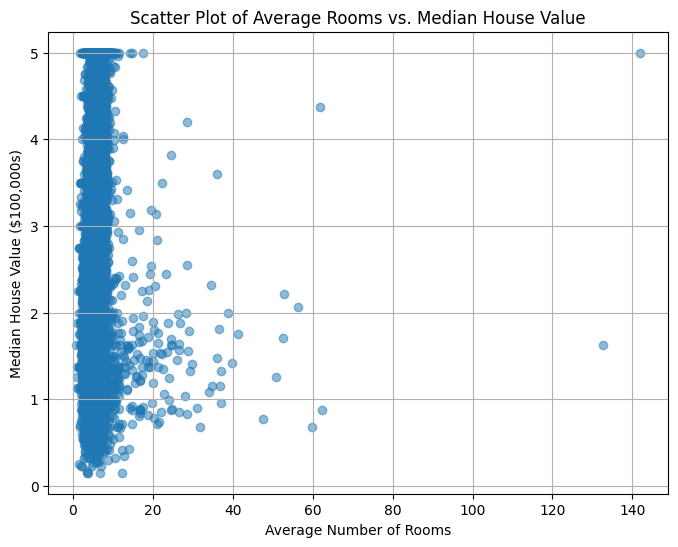

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X["AveRooms"], y, alpha=0.5)
#plt.xlim(1, 20)
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Scatter Plot of Average Rooms vs. Median House Value")
plt.grid(True)
plt.show()

In [ ]:
X_train.head()

,AveRooms
14196,5.017657
8267,4.473545
17445,5.645833
14265,4.002817
2271,6.268421


In [ ]:
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(X_train)
print(X_train_scaled)
# Also transform test data.
X_test_scaled = scaler.transform(X_test)
print(X_test_scaled)

[[-0.17491646]
 [-0.40283542]
 [ 0.08821601]
 ...
 [-0.60675918]
 [ 0.40217517]
 [-0.85144571]]
[[-0.52068576]
 [-0.16581537]
 [-0.61076476]
 ...
 [ 0.75501156]
 [-0.06124296]
 [-0.6058703 ]]


In [ ]:
# Import LinearRegression.
from sklearn.linear_model import LinearRegression


# Instantiate linear regression model.
model = LinearRegression()

In [ ]:
# Fit the model to the training data.
reg=model.fit(X_train_scaled, y_train)
print(reg.coef_)
print(reg.intercept_)

[0.18323882]
2.071946937378876


In [ ]:
# Make predictions on the testing data.
y_pred = reg.predict(X_test_scaled)
y_pred

array([1.97653709, 2.04156313, 1.96003112, ..., 2.21029436, 2.06072485,
       1.96092798])

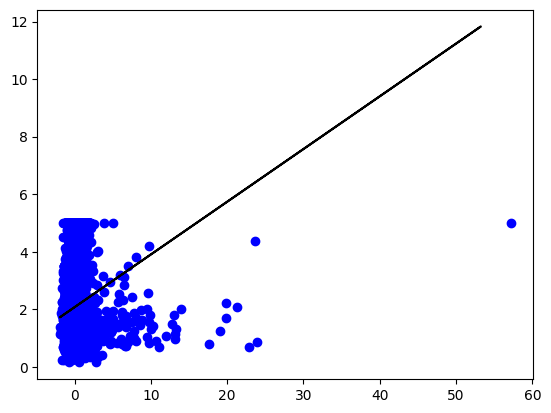

In [ ]:
plt.scatter(X_train_scaled, y_train, color ='b')
plt.plot(X_test_scaled, y_pred, color ='k')

plt.show()

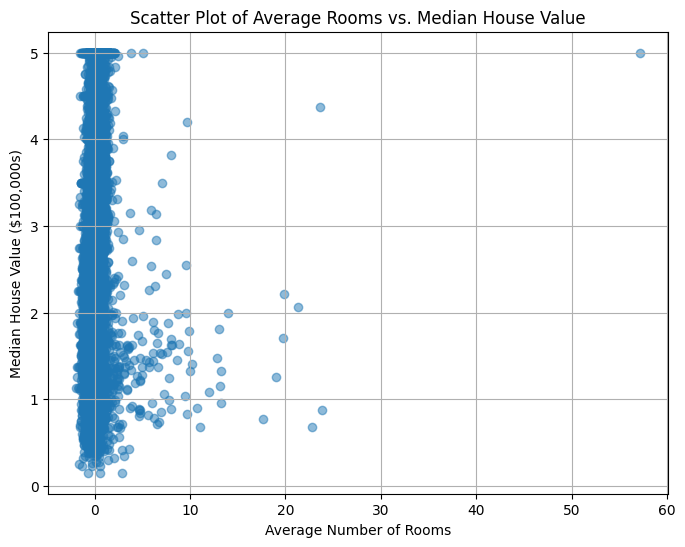

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_scaled, y_train, alpha=0.5)
#plt.xlim(1, 20)
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Scatter Plot of Average Rooms vs. Median House Value")
plt.grid(True)
plt.show()

In [ ]:
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score


# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.0138


In [ ]:
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 1.2923
Root mean squared error: 1.1368
